# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download E-Commerce Sales and Data Dataset](https://www.kaggle.com/datasets/sohaibdevv/e-commerce-sales-and-profit-analysis)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('ecommerce_sales_data (2).csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


## last Five row

In [4]:
df.tail()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28
3499,2024-11-01,Smartwatch,Electronics,East,9,10530,1777.32


## Shape of our dataset

In [5]:
df.shape

(3500, 7)

## List out all columns

In [6]:
df.columns

Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Order Date       object
Product Name     object
Category         object
Region           object
Quantity          int64
Sales             int64
Profit          float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


## Check Null Value

In [9]:
df.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

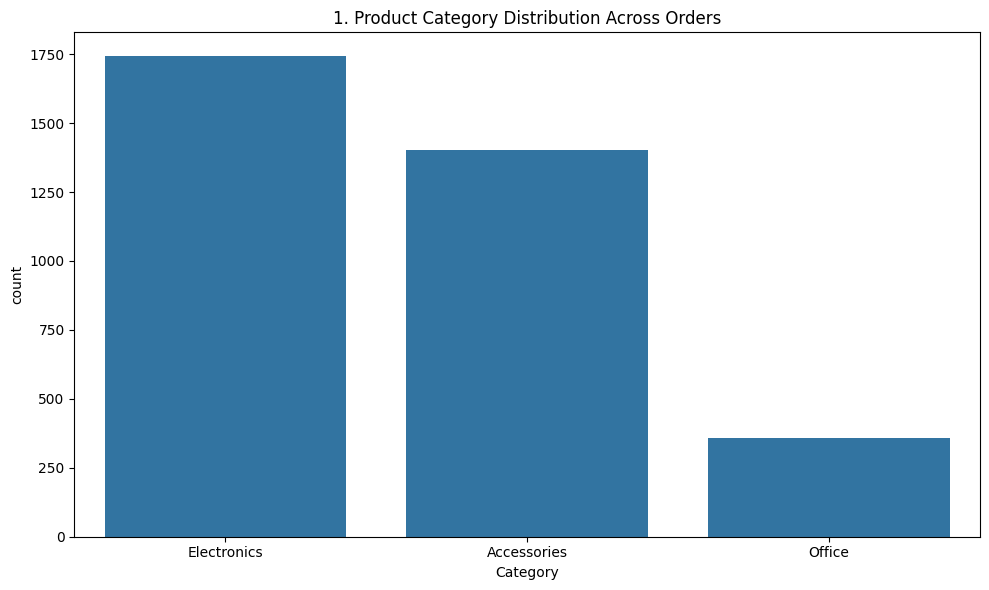

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Category', data=df, order=df['Category'].value_counts().index)
plt.title(f'{plot_no}. Product Category Distribution Across Orders')
show_fig()
plot_no += 1

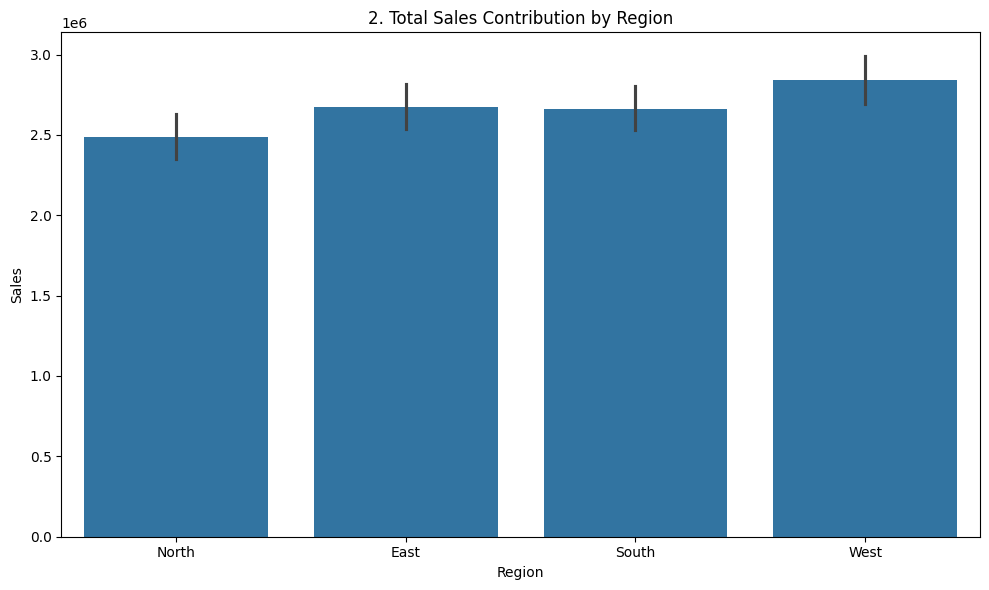

In [14]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='Region', y='Sales', data=df, estimator=sum)
plt.title(f'{plot_no}. Total Sales Contribution by Region')
show_fig()
plot_no += 1

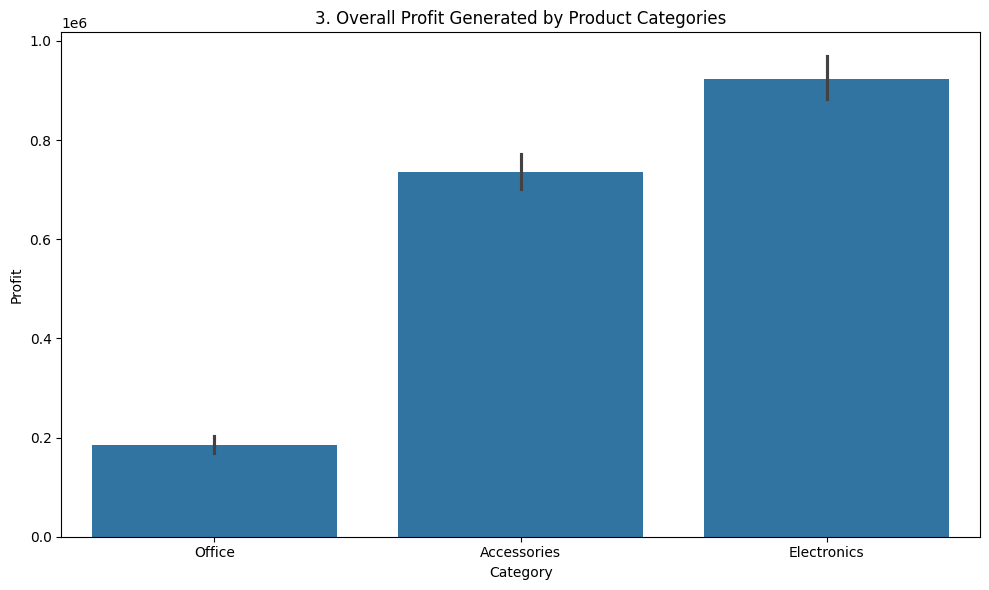

In [15]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='Category', y='Profit', data=df, estimator=sum)
plt.title(f'{plot_no}. Overall Profit Generated by Product Categories')
show_fig()
plot_no += 1

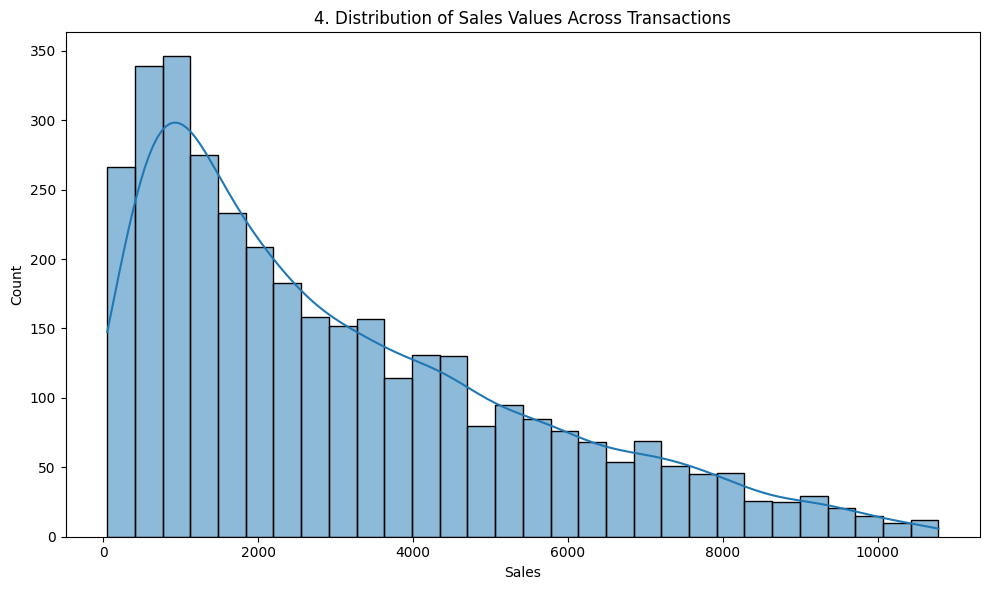

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Sales'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Sales Values Across Transactions')
show_fig()
plot_no += 1

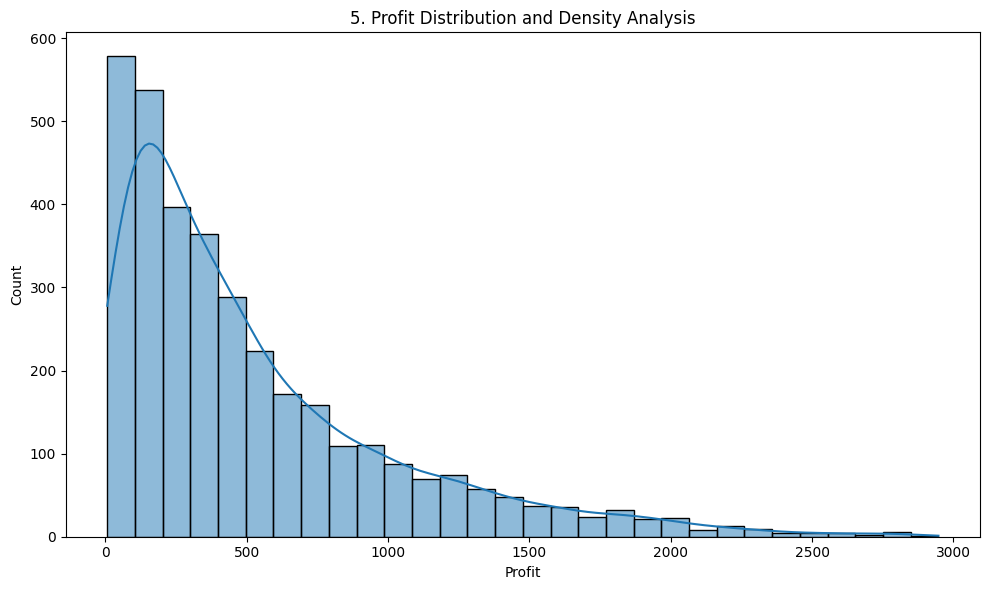

In [17]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Profit'], bins=30, kde=True)
plt.title(f'{plot_no}. Profit Distribution and Density Analysis')
show_fig()
plot_no += 1

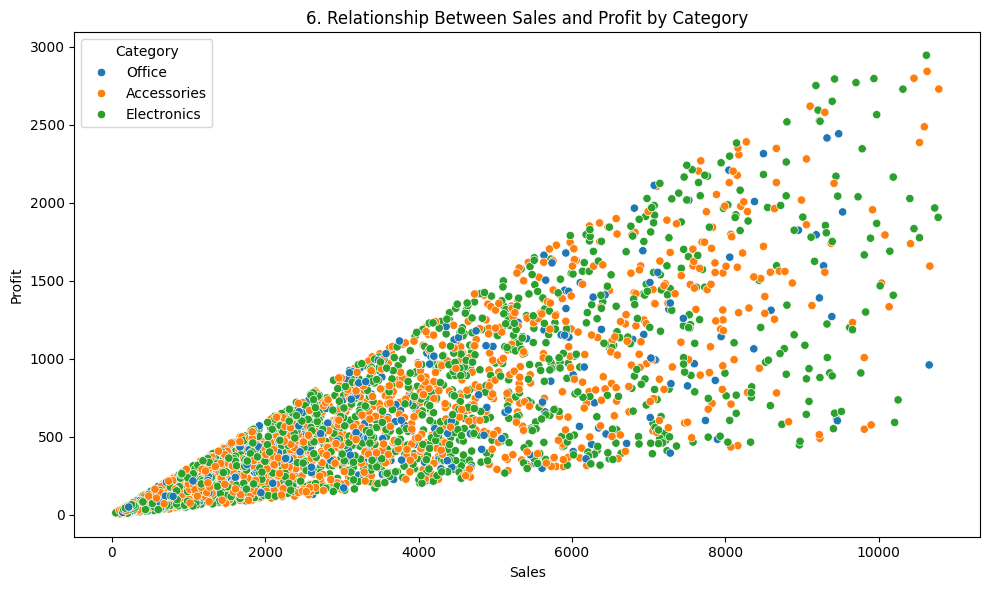

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Sales', y='Profit', hue='Category', data=df)
plt.title(f'{plot_no}. Relationship Between Sales and Profit by Category')
show_fig()
plot_no += 1

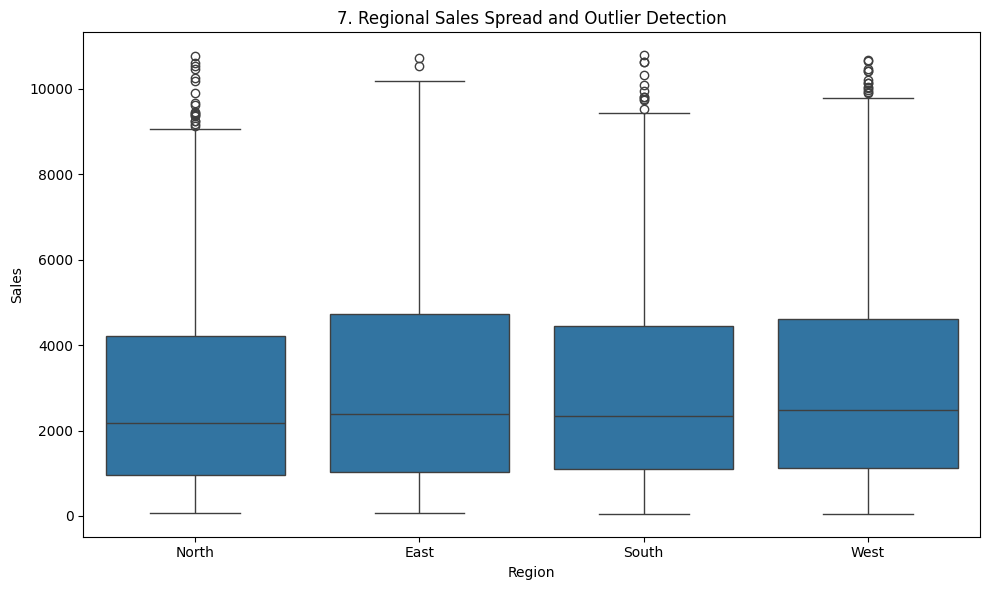

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Region', y='Sales', data=df)
plt.title(f'{plot_no}. Regional Sales Spread and Outlier Detection')
show_fig()
plot_no += 1

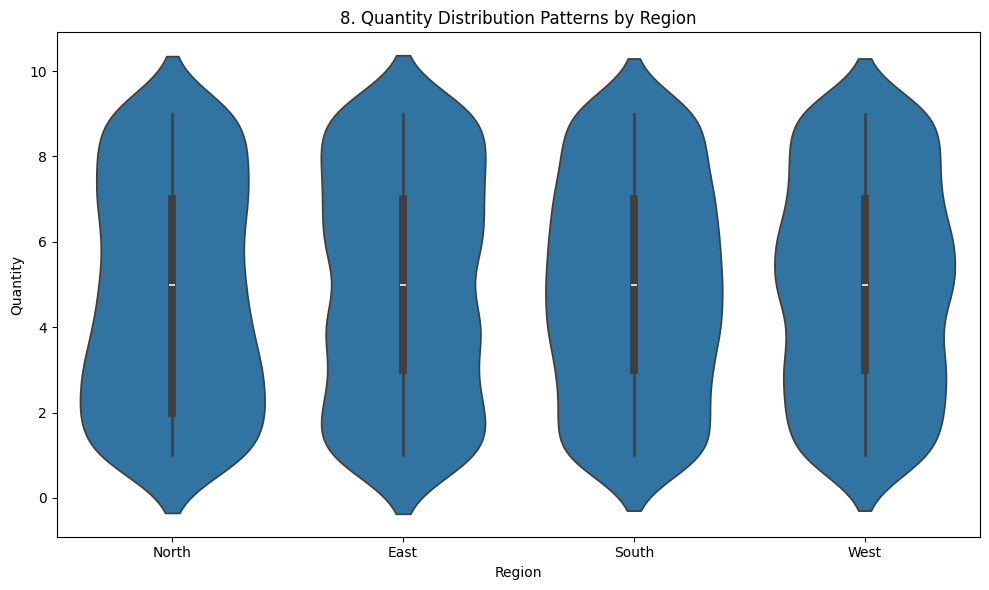

In [20]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='Region', y='Quantity', data=df)
plt.title(f'{plot_no}. Quantity Distribution Patterns by Region')
show_fig()
plot_no += 1

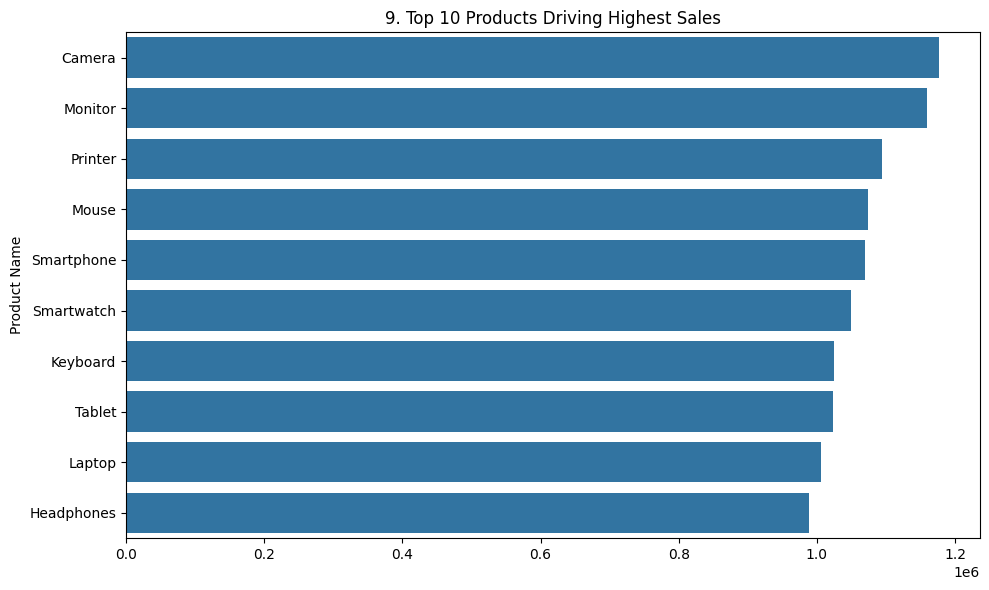

In [21]:
fig = plt.figure(figsize=(10,6))
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index)
plt.title(f'{plot_no}. Top 10 Products Driving Highest Sales')
show_fig()
plot_no += 1

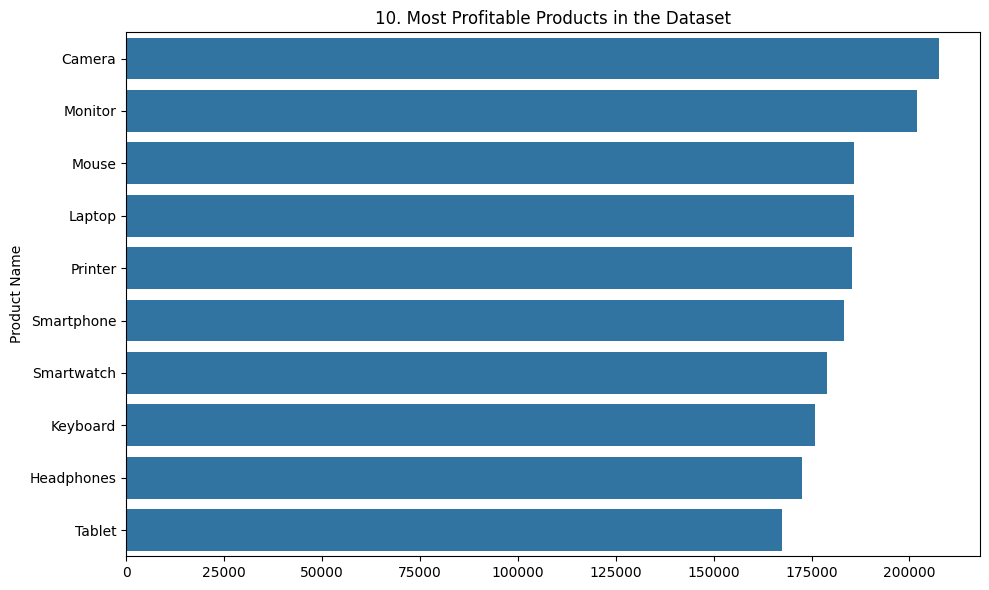

In [22]:
fig = plt.figure(figsize=(10,6))
top_profit_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_profit_products.values, y=top_profit_products.index)
plt.title(f'{plot_no}. Most Profitable Products in the Dataset')
show_fig()
plot_no += 1

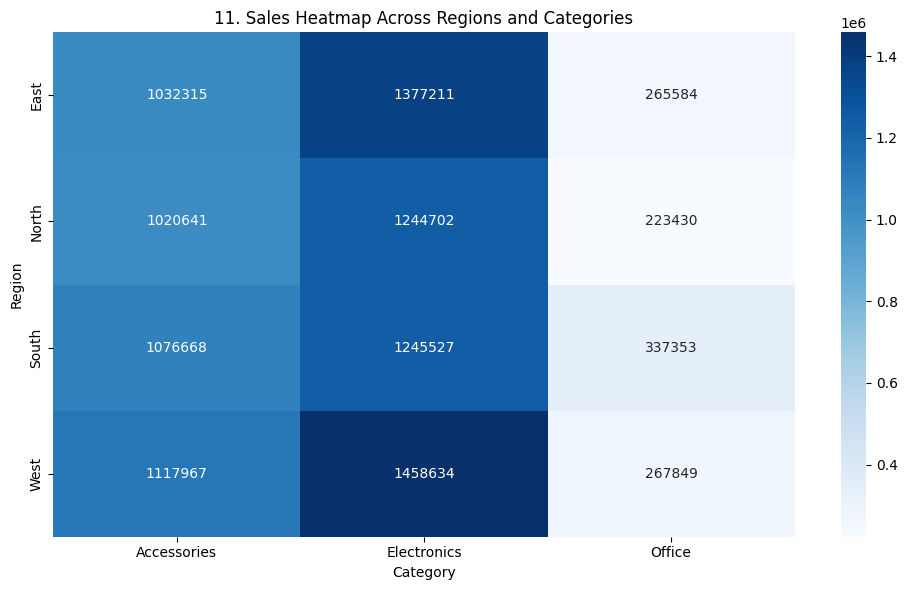

In [23]:
fig = plt.figure(figsize=(10,6))
region_category_sales = df.pivot_table(values='Sales', index='Region', columns='Category', aggfunc='sum')
sns.heatmap(region_category_sales, annot=True, fmt='.0f', cmap='Blues')
plt.title(f'{plot_no}. Sales Heatmap Across Regions and Categories')
show_fig()
plot_no += 1

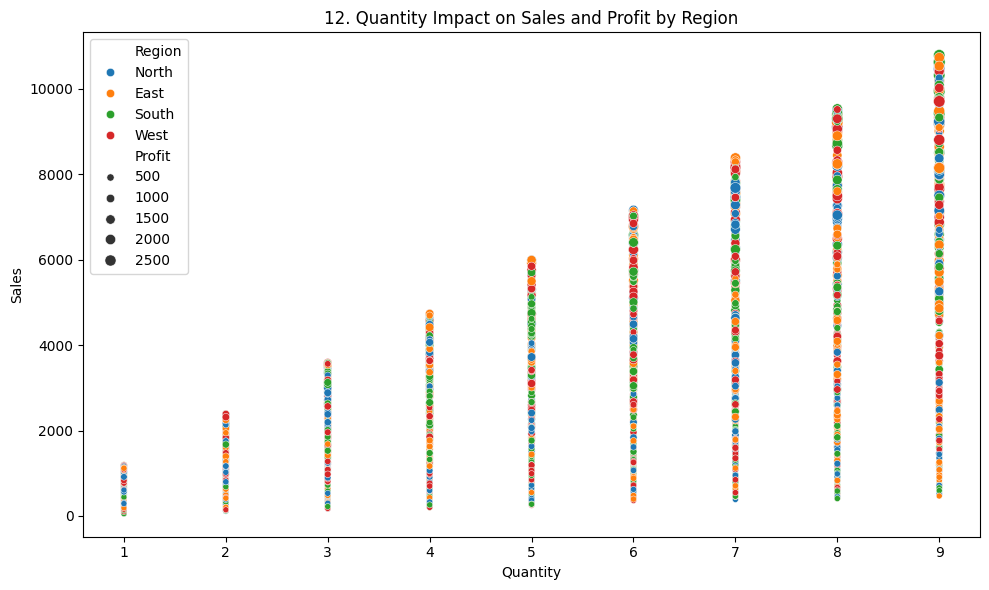

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Quantity', y='Sales', size='Profit', hue='Region', data=df)
plt.title(f'{plot_no}. Quantity Impact on Sales and Profit by Region')
show_fig()
plot_no += 1

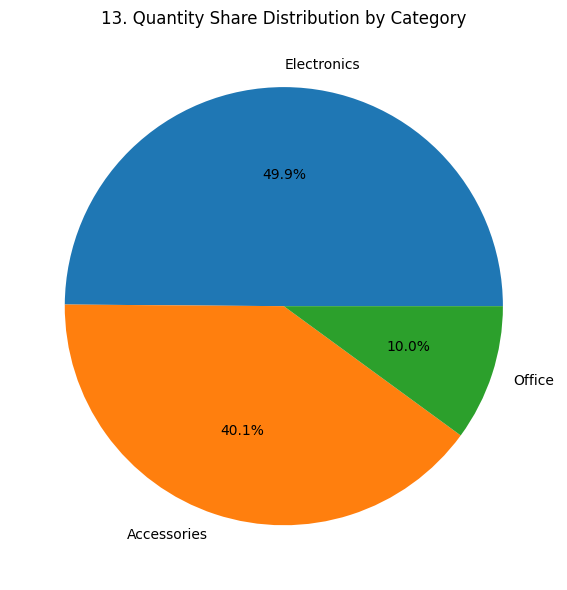

In [25]:
fig = plt.figure(figsize=(10,6))
category_quantity = df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)
plt.pie(category_quantity.values, labels=category_quantity.index, autopct='%1.1f%%')
plt.title(f'{plot_no}. Quantity Share Distribution by Category')
show_fig()
plot_no += 1

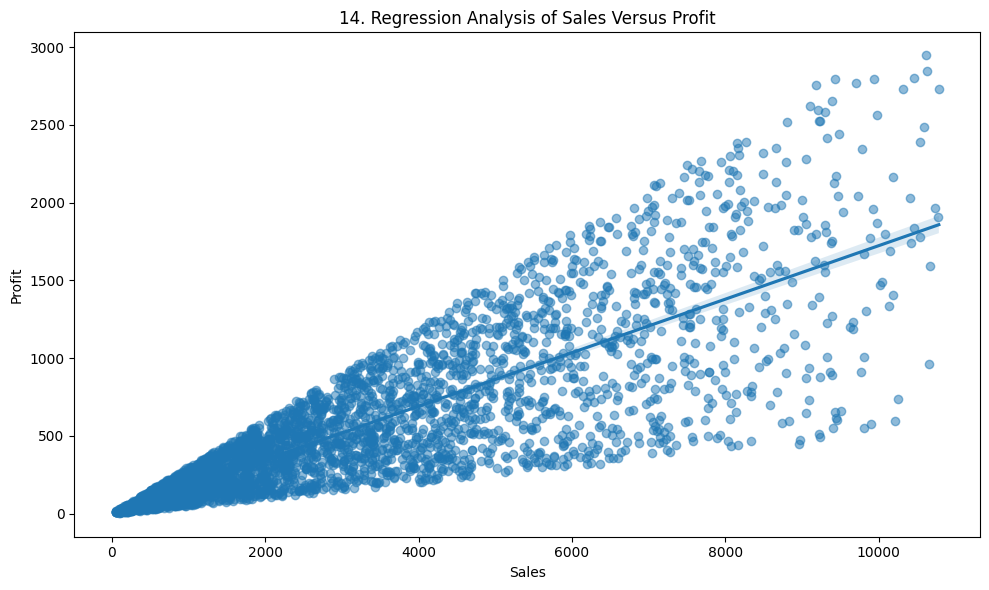

In [26]:
fig = plt.figure(figsize=(10,6))
sns.regplot(x='Sales', y='Profit', data=df, scatter_kws={'alpha':0.5})
plt.title(f'{plot_no}. Regression Analysis of Sales Versus Profit')
show_fig()
plot_no += 1

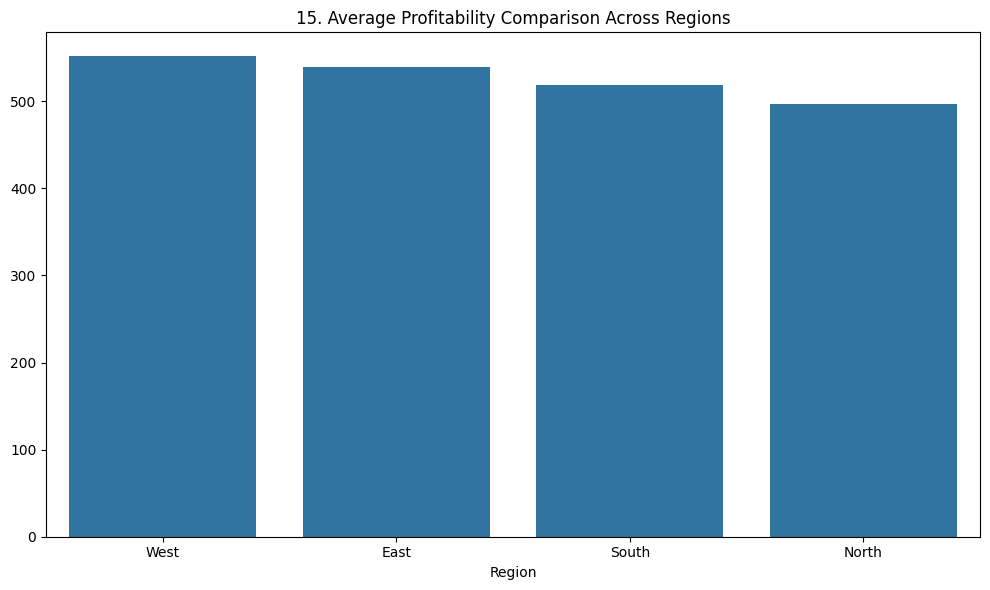

In [27]:
fig = plt.figure(figsize=(10,6))
avg_profit_region = df.groupby('Region')['Profit'].mean().sort_values(ascending=False)
sns.barplot(x=avg_profit_region.index, y=avg_profit_region.values)
plt.title(f'{plot_no}. Average Profitability Comparison Across Regions')
show_fig()
plot_no += 1

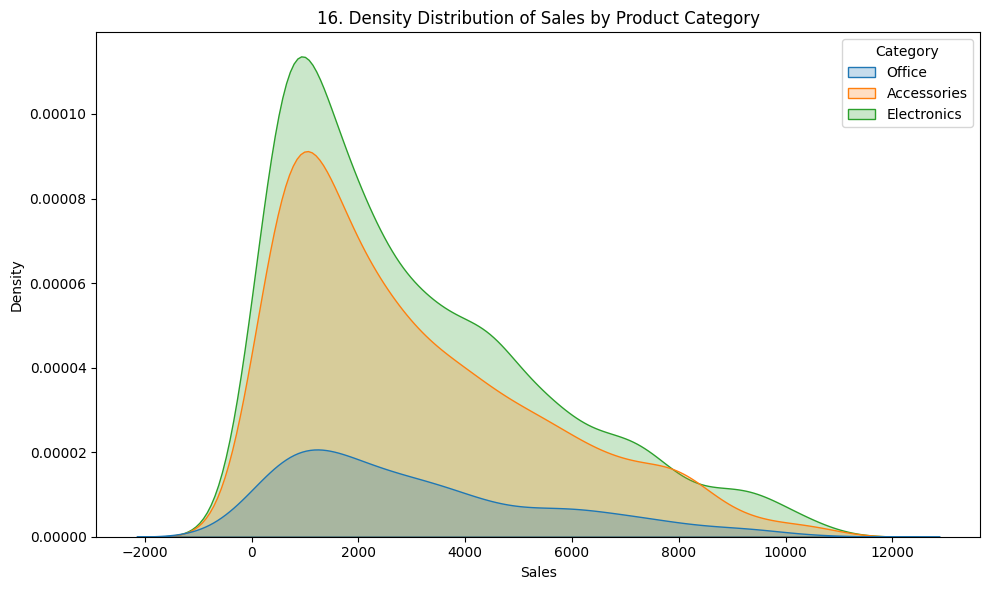

In [28]:
fig = plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='Sales', hue='Category', fill=True)
plt.title(f'{plot_no}. Density Distribution of Sales by Product Category')
show_fig()
plot_no += 1

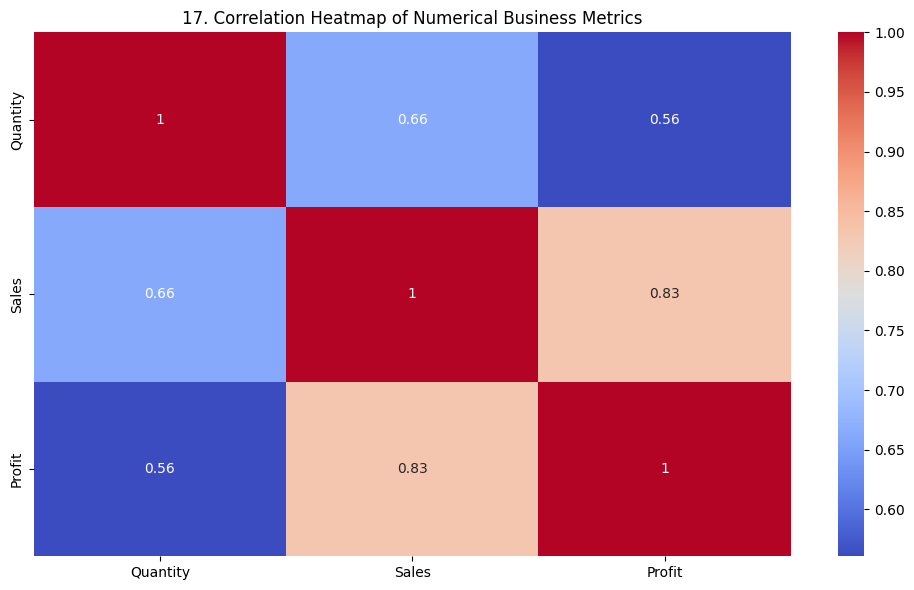

In [29]:
fig = plt.figure(figsize=(10,6))
corr = df[['Quantity', 'Sales', 'Profit']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Business Metrics')
show_fig()
plot_no += 1